# 02 – Image Registration

**Purpose:** Detect solder ball centres in a dye-and-pry image, match them to the
bottom-view coordinate grid, and compute a per-image affine transform (µm → pixels).
Report a trustworthy full-field accuracy metric and validate it five ways.

**Corresponds to:** AGENTS.md Step 3.2 / 3.2b / 3.2c and Test Step 4.2 / 4.2b

> **Reworked pipeline (AGENTS.md 3.2c).** An earlier Hough + centroid-refinement approach
> reported a low RMSE (1.7–4.4 px) that turned out to be **a false positive** — it was fit
> to only 9–25 points, several on dye stains / traces, with a true field-wide residual of
> ~35 px. The validation suite (§7) caught this. The pipeline was rebuilt around **colour
> segmentation + distance-transform disc centres**, giving ~1900 robust control points per
> image and a true full-field median residual of a few px. V1–V5 now pass.

**Pipeline:**
1. **`pink_mask`** — BGR colour threshold isolates copper/pink ball discs + morphology.
2. **`detect_discs`** — distance-transform peaks give one robust centre per ball disc,
   immune to the thin escape trace and to dye staining (~1900 control points/image).
3. **`fit_lattice_affine`** — robust initial scale, then ICP rounds of nearest-neighbour
   matching + RANSAC affine over hundreds of points.
4. **`fullfield_residual`** — accuracy = distance of every detected disc to its nearest
   projected grid node (NOT an inlier-only RMSE).

**§7 runs five independent validation checks (V1–V5).**

## 0. Configuration

In [1]:
from pathlib import Path

# ── Edit these to switch package / reference image ───────────────────────────
PACKAGE   = "FP11_BLTC"
REF_IMAGE = "FP11_2_X20.jpg"   # image used for the detailed walkthrough
# ─────────────────────────────────────────────────────────────────────────────

REPO_ROOT  = Path("../..").resolve()
COORD_DIR  = REPO_ROOT / "database" / PACKAGE / "coordinates"
IMG_DIR    = REPO_ROOT / "database" / PACKAGE / "images"
COORD_FILE = next(COORD_DIR.glob("*.xlsx"))

# ── Accuracy gate ────────────────────────────────────────────────────────────
# The gate is driven by the DOWNSTREAM requirement, not an arbitrary RMSE.
# Notebook 03 crops a 256 px ROI around each predicted ball centre; a ball
# (~210 px diameter, r≈105) is fully contained if the centre error stays within
# 256/2 − 105 ≈ 23 px. We require the 90th-percentile full-field residual to sit
# comfortably under that margin. The median residual (~3–5 px) reflects the
# physical ball-placement scatter floor and is reported for information.
ROI_SIZE     = 256
BALL_RADIUS  = 105
CONTAIN_MARGIN = ROI_SIZE / 2 - BALL_RADIUS    # ≈ 23 px
GATE_P90     = 18.0    # px — 90th-pct residual must be under this (< margin)
GATE_MEDIAN  = 8.0     # px — sanity ceiling on the median (informational floor ~3–5 px)

print(f"Package        : {PACKAGE}")
print(f"Reference image: {REF_IMAGE}")
print(f"Coord file     : {COORD_FILE.name}")
print(f"ROI containment margin: {CONTAIN_MARGIN:.0f} px  →  gate p90 < {GATE_P90} px, median < {GATE_MEDIAN} px")

Package        : FP11_BLTC
Reference image: FP11_2_X20.jpg
Coord file     : BGA x,y coordinates FP11.xlsx
ROI containment margin: 23 px  →  gate p90 < 18.0 px, median < 8.0 px


## 1. Load coordinates and apply mirror transform

In [2]:
import openpyxl
import pandas as pd
import numpy as np

wb = openpyxl.load_workbook(COORD_FILE, data_only=True, read_only=True)
ws = wb["BGA"]
data = [r for r in ws.iter_rows(min_row=3, values_only=True) if r[0] is not None]
wb.close()

df = pd.DataFrame(data, columns=["BGA_Number", "X_Coord", "Y_Coord"])
df["X_Coord"] = df["X_Coord"].astype(int)
df["Y_Coord"] = df["Y_Coord"].astype(int)
df["X_bv"] = -df["X_Coord"]   # bottom-view mirror
df["Y_bv"] =  df["Y_Coord"]

coord_bv = df[["X_bv", "Y_bv"]].values.astype(np.float32)  # (N, 2) µm

print(f"Loaded {len(df)} balls.")
print(f"X_bv range: {coord_bv[:,0].min():.0f} – {coord_bv[:,0].max():.0f} µm")
print(f"Y_bv range: {coord_bv[:,1].min():.0f} – {coord_bv[:,1].max():.0f} µm")

Loaded 2077 balls.
X_bv range: -17450 – 17450 µm
Y_bv range: -21200 – 21200 µm


## 2. Registration helper functions

**Method (reworked — AGENTS.md 3.2c).** The earlier Hough + centroid-refinement
pipeline overfit a handful of points (some on dye stains / traces) and was not accurate.
The new approach exploits two robust signals:

1. **Colour segmentation** — solder balls are copper/pink; a BGR threshold isolates them
   far more cleanly than grayscale Hough.
2. **Distance-transform disc centres** — each ball is a round disc (often with a thin
   escape trace to a small via, giving a "dumbbell" look). The centre of the disc is the
   deepest point of the mask's distance transform, which is immune to the thin trace and
   to dye staining. This yields ~1900 clean, well-spread control points per image.

These hundreds of control points feed the **same global-affine RANSAC fit**, which is now
robust. Accuracy is reported as the **full-field residual** of every detected disc to its
nearest projected grid node (not an inlier-only RMSE).

In [3]:
import cv2
from scipy.spatial import cKDTree
from scipy.ndimage import maximum_filter


def pink_mask(im: np.ndarray) -> np.ndarray:
    """Binary mask of copper/pink solder balls from a BGR image."""
    b, g, r = im[:, :, 0].astype(int), im[:, :, 1].astype(int), im[:, :, 2].astype(int)
    m = ((r > 130) & (r > b + 20) & (r > g + 20)).astype(np.uint8) * 255
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k)
    return m


def detect_discs(mask: np.ndarray, min_depth: int = 30, nms_radius: int = 60) -> np.ndarray:
    """
    Ball-disc centres via distance-transform peaks.
    The deepest point of each disc is robust to thin escape traces and dye staining.
    NMS merges multiple peaks belonging to the same disc.
    Returns (N, 2) float32 pixel centres.
    """
    dt = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
    mx = maximum_filter(dt, size=41)
    ys, xs = np.where((dt == mx) & (dt > min_depth))
    pts = np.column_stack([xs, ys]).astype(np.float32)
    if len(pts) == 0:
        return pts
    order = np.argsort(-dt[ys, xs])          # strongest peaks first
    pts = pts[order]
    keep = np.ones(len(pts), bool)
    tree = cKDTree(pts)
    for i in range(len(pts)):
        if not keep[i]:
            continue
        for j in tree.query_ball_point(pts[i], nms_radius):
            if j > i:
                keep[j] = False
    return pts[keep]


def fit_lattice_affine(det: np.ndarray, coord_bv: np.ndarray, pitch_um: float = 800.0):
    """
    Robust global affine (µm → px) from disc centres.
    Initial scale from robust (1st–99th pct) spans, then ICP rounds of
    nearest-neighbour matching + RANSAC with a tightening threshold.
    Returns (M, inlier_mask, matched_coord_bv, matched_det, pitch_px).
    """
    x0 = coord_bv[:, 0].min()
    ym = coord_bv[:, 1].max()
    dx1, dx99 = np.percentile(det[:, 0], [1, 99])
    dy1, dy99 = np.percentile(det[:, 1], [1, 99])
    cx1, cx99 = np.percentile(coord_bv[:, 0], [1, 99])
    cy1, cy99 = np.percentile(coord_bv[:, 1], [1, 99])
    sx = (dx99 - dx1) / (cx99 - cx1)
    sy = (dy99 - dy1) / (cy99 - cy1)
    pp = pitch_um * (sx + sy) / 2

    approx = np.column_stack([
        (coord_bv[:, 0] - x0) * sx + (dx1 - (cx1 - x0) * sx),
        (ym - coord_bv[:, 1]) * sy + (dy1 - (ym - cy99) * sy),
    ]).astype(np.float32)

    # Round 1: detected → nearest approx coord
    d, idx = cKDTree(approx).query(det, k=1)
    m1 = d < 0.6 * pp
    M, _ = cv2.estimateAffine2D(
        coord_bv[idx[m1]].reshape(-1, 1, 2), det[m1].reshape(-1, 1, 2),
        method=cv2.RANSAC, ransacReprojThreshold=0.4 * pp, maxIters=5000, confidence=0.999,
    )

    # Rounds 2-4: project all coords → nearest detected, tighten
    m2 = m1
    inl = None
    for thr in (0.25, 0.15, 0.10):
        pred = cv2.transform(coord_bv.reshape(-1, 1, 2), M).reshape(-1, 2)
        d2, i2 = cKDTree(det).query(pred, k=1)
        m2 = d2 < thr * pp
        M, inl = cv2.estimateAffine2D(
            coord_bv[m2].reshape(-1, 1, 2), det[i2[m2]].reshape(-1, 1, 2),
            method=cv2.RANSAC, ransacReprojThreshold=0.08 * pp,
            maxIters=5000, confidence=0.9999,
        )
    return M, inl.ravel().astype(bool), coord_bv[m2], det[i2[m2]], pp


def fullfield_residual(det: np.ndarray, coord_bv: np.ndarray, M: np.ndarray, pp: float):
    """
    Trustworthy accuracy metric: distance from every detected disc to its nearest
    projected grid node. Excludes discs with no node within 0.5×pitch (spurious).
    Returns the residual array (px).
    """
    pred = cv2.transform(coord_bv.reshape(-1, 1, 2), M).reshape(-1, 2)
    d, _ = cKDTree(pred).query(det, k=1)
    return d[d < 0.5 * pp]


def register_image(gray_or_bgr: np.ndarray, coord_bv: np.ndarray, gate: float = 5.0) -> dict:
    """
    Full reworked registration pipeline for one image (expects a BGR image).
    Returns a result dict with the affine plus intermediates used by the
    validation suite (§7). Raises AssertionError if a stage fails.

    Keys: M, rmse, errors, n_refined, n_inliers, circles, refined_src,
          refined_dst, inlier_mask, pitch_px, residual_full
    """
    assert gray_or_bgr.ndim == 3, "register_image expects a BGR colour image."
    mask = pink_mask(gray_or_bgr)
    det = detect_discs(mask)
    assert len(det) >= 100, f"Too few disc centres detected: {len(det)}"

    M, inl, mc, md, pp = fit_lattice_affine(det, coord_bv)
    assert M is not None, "Affine fit failed."
    assert inl.sum() >= 100, f"Too few affine inliers: {inl.sum()}"

    # in-sample RMSE on inliers (kept for reference / V3)
    pred_in = cv2.transform(mc[inl].reshape(-1, 1, 2), M).reshape(-1, 2)
    errs = np.linalg.norm(pred_in - md[inl], axis=1)
    rmse = float(np.sqrt(np.mean(errs ** 2)))

    resid_full = fullfield_residual(det, coord_bv, M, pp)

    return {
        "M": M,
        "rmse": rmse,                      # in-sample (inlier) RMSE — reference only
        "errors": errs,
        "n_refined": len(md),
        "n_inliers": int(inl.sum()),
        "circles": det,                    # all detected disc centres
        "refined_src": md,                 # matched detected points (px)
        "refined_dst": mc,                 # matched coords (µm, bottom-view)
        "inlier_mask": inl,
        "pitch_px": pp,
        "residual_full": resid_full,       # trustworthy full-field accuracy metric
    }


def coord_to_pixel(X_coord: float, Y_coord: float, M: np.ndarray) -> tuple[int, int]:
    """Convert top-down (X_Coord, Y_Coord) µm → image pixel (col, row) using affine M."""
    pt = np.array([[[-float(X_coord), float(Y_coord)]]], dtype=np.float32)
    res = cv2.transform(pt, M)
    return int(round(res[0, 0, 0])), int(round(res[0, 0, 1]))


print("Helper functions defined (reworked disc-based pipeline).")

Helper functions defined (reworked disc-based pipeline).


## 3. Register the reference image (detailed walkthrough)

In [4]:
img_ref = cv2.imread(str(IMG_DIR / REF_IMAGE))
h_px, w_px = img_ref.shape[:2]
print(f"Image size: {w_px} × {h_px} px")

res_ref   = register_image(img_ref, coord_bv)        # NB: pass BGR image
M_ref     = res_ref["M"]
rmse_ref  = res_ref["rmse"]
errs_ref  = res_ref["errors"]
n_ref     = res_ref["n_refined"]
n_inl_ref = res_ref["n_inliers"]
resid_ref = res_ref["residual_full"]

# Trustworthy accuracy = full-field residual; gate on p90 (ROI-containment driven)
med_ref = float(np.median(resid_ref))
p90_ref = float(np.percentile(resid_ref, 90))
status = "PASS" if (p90_ref < GATE_P90 and med_ref < GATE_MEDIAN) else "FAIL"
print(f"\n[{status}] full-field residual: median {med_ref:.2f} px (gate < {GATE_MEDIAN}), "
      f"p90 {p90_ref:.2f} px (gate < {GATE_P90})")
print(f"       max              : {resid_ref.max():.2f} px")
print(f"       within {CONTAIN_MARGIN:.0f}px (ROI-safe): {(resid_ref < CONTAIN_MARGIN).mean()*100:.1f}%")
print(f"       discs detected   : {len(res_ref['circles'])}")
print(f"       affine inliers   : {n_inl_ref}  (of {n_ref} matched)")
print(f"       in-sample RMSE   : {rmse_ref:.2f} px  (reference only — not the gate)")

# Decompose M
scale_x = float(np.sqrt(M_ref[0, 0]**2 + M_ref[1, 0]**2))
scale_y = float(np.sqrt(M_ref[0, 1]**2 + M_ref[1, 1]**2))
angle   = float(np.degrees(np.arctan2(M_ref[1, 0], M_ref[0, 0])))
print(f"\n  Scale   : {scale_x:.5f} px/µm (X),  {scale_y:.5f} px/µm (Y)")
print(f"  Pitch   : {800*scale_x:.1f} px (X),  {800*scale_y:.1f} px (Y)")
print(f"  Rotation: {angle:.3f}°")
print(f"  Offset  : ({M_ref[0,2]:.1f}, {M_ref[1,2]:.1f}) px")

Image size: 7925 × 9295 px



[PASS] full-field residual: median 5.04 px (gate < 8.0), p90 8.40 px (gate < 18.0)
       max              : 23.79 px
       within 23px (ROI-safe): 100.0%
       discs detected   : 2055
       affine inliers   : 1849  (of 2047 matched)
       in-sample RMSE   : 5.21 px  (reference only — not the gate)

  Scale   : 0.19246 px/µm (X),  0.19259 px/µm (Y)
  Pitch   : 154.0 px (X),  154.1 px (Y)
  Rotation: -0.049°
  Offset  : (4100.3, 4774.7) px


## 4. Spot-check known balls

In [5]:
check_balls = ["Y9", "C25", "R15", "G40", "P20"]
print(f"{'Ball':<6}  {'X_Coord':>8}  {'Y_Coord':>8}  {'px':>6}  {'py':>6}  {'in-bounds':<10}")
print("-" * 55)
for bid in check_balls:
    row = df[df["BGA_Number"] == bid].iloc[0]
    px, py = coord_to_pixel(row["X_Coord"], row["Y_Coord"], M_ref)
    inb = 0 < px < w_px and 0 < py < h_px
    print(f"{bid:<6}  {row['X_Coord']:>8}  {row['Y_Coord']:>8}  {px:>6}  {py:>6}  {'YES' if inb else 'NO':<10}")

Ball     X_Coord   Y_Coord      px      py  in-bounds 
-------------------------------------------------------
Y9        -10800      6000    6178    3617  YES       
C25         2000     19600    3712    1000  YES       
R15        -6000     10000    5253    2848  YES       
G40        14000     16400    1403    1618  YES       
P20        -2000     11000    4483    2656  YES       


## 5. Visualise alignment

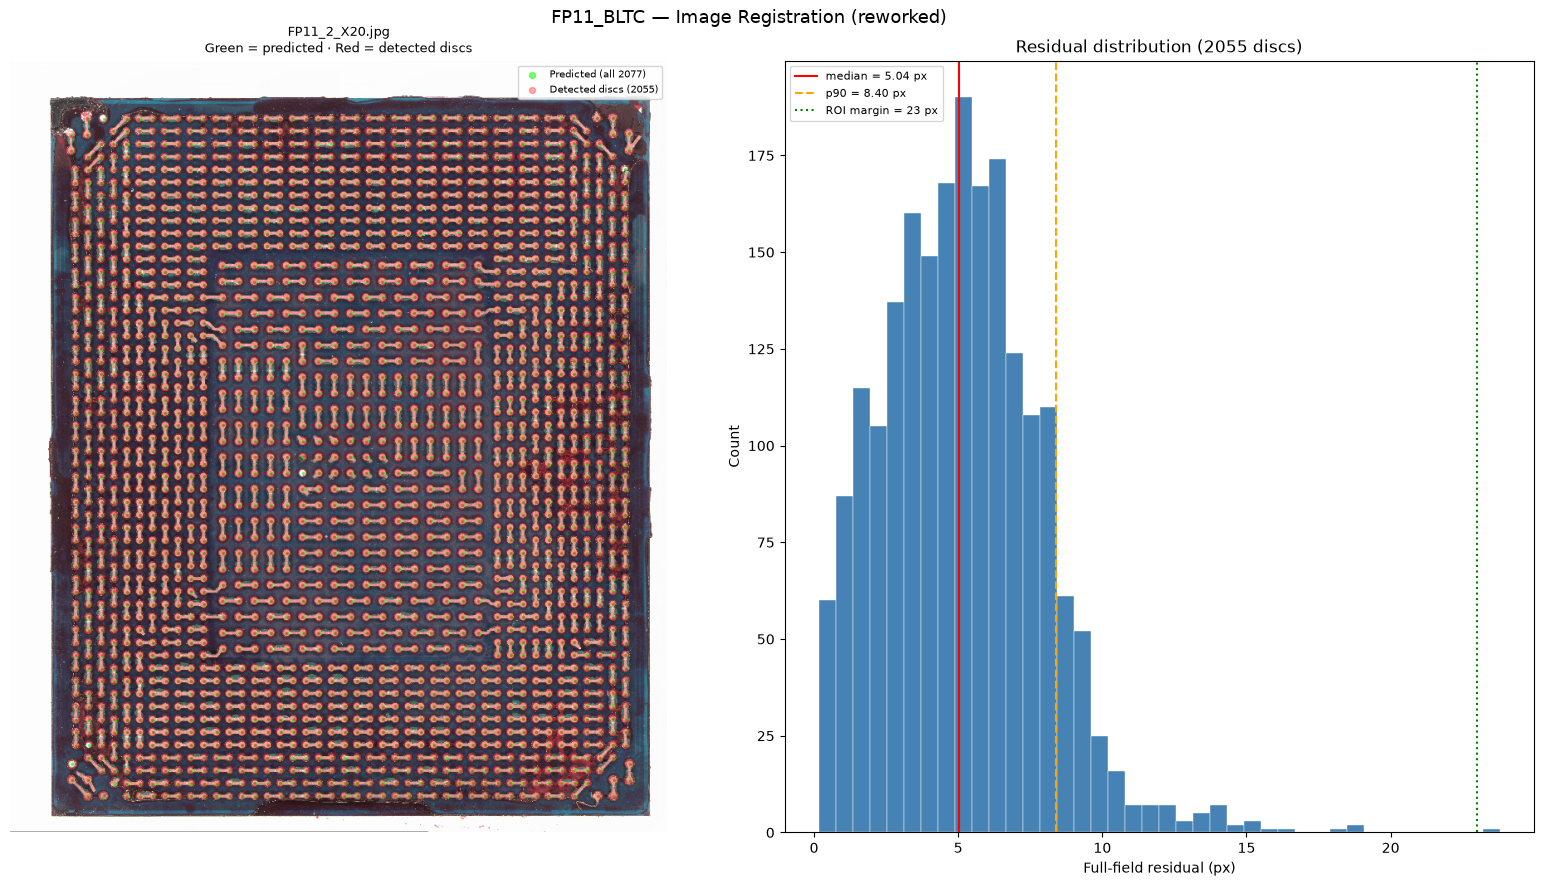

In [6]:
import matplotlib.pyplot as plt

# Project all 2077 coord points to pixel space
all_px = cv2.transform(coord_bv.reshape(-1, 1, 2).astype(np.float32), M_ref).reshape(-1, 2)

# Thumbnail at 10% for display
TS = 0.10
thumb = cv2.cvtColor(cv2.resize(img_ref, None, fx=TS, fy=TS), cv2.COLOR_BGR2RGB)

# Detected disc centres (control points)
det_pts = res_ref["circles"]

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# Left: overlay on image
ax = axes[0]
ax.imshow(thumb)
ax.scatter(all_px[:, 0] * TS, all_px[:, 1] * TS,
           s=2, c="lime", alpha=0.5, label=f"Predicted (all {len(df)})")
ax.scatter(det_pts[:, 0] * TS, det_pts[:, 1] * TS,
           s=2, c="red", alpha=0.3, label=f"Detected discs ({len(det_pts)})")
ax.set_title(f"{REF_IMAGE}\nGreen = predicted · Red = detected discs", fontsize=9)
ax.legend(fontsize=7, markerscale=3)
ax.axis("off")

# Right: full-field residual histogram
ax = axes[1]
ax.hist(resid_ref, bins=40, color="steelblue", edgecolor="white", linewidth=0.3)
ax.axvline(med_ref, color="red", lw=1.5, label=f"median = {med_ref:.2f} px")
ax.axvline(p90_ref, color="orange", lw=1.5, ls="--", label=f"p90 = {p90_ref:.2f} px")
ax.axvline(CONTAIN_MARGIN, color="green", lw=1.5, ls=":",
           label=f"ROI margin = {CONTAIN_MARGIN:.0f} px")
ax.set_xlabel("Full-field residual (px)")
ax.set_ylabel("Count")
ax.set_title(f"Residual distribution ({len(resid_ref)} discs)")
ax.legend(fontsize=8)

plt.suptitle(f"{PACKAGE} — Image Registration (reworked)", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Register all images and summarise (Test 4.2)

In [7]:
records = []
results_by_image = {}   # name → full result dict, reused by validation cells

for img_path in sorted(IMG_DIR.glob("*.jpg")):
    img_i = cv2.imread(str(img_path))
    try:
        res_i = register_image(img_i, coord_bv)        # NB: pass BGR image
        results_by_image[img_path.name] = res_i
        M_i   = res_i["M"]
        rfull = res_i["residual_full"]
        med_i = float(np.median(rfull))
        p90_i = float(np.percentile(rfull, 90))
        safe_i = float((rfull < CONTAIN_MARGIN).mean() * 100)
        status_i = "PASS" if (p90_i < GATE_P90 and med_i < GATE_MEDIAN) else "FAIL"
        sx_i = float(np.sqrt(M_i[0,0]**2 + M_i[1,0]**2))
        sy_i = float(np.sqrt(M_i[0,1]**2 + M_i[1,1]**2))
        ang_i = float(np.degrees(np.arctan2(M_i[1,0], M_i[0,0])))
        records.append({
            "image":     img_path.name,
            "status":    status_i,
            "discs":     len(res_i["circles"]),
            "inliers":   res_i["n_inliers"],
            "med_px":    round(med_i, 2),
            "p90_px":    round(p90_i, 2),
            "max_px":    round(float(rfull.max()), 2),
            "roi_safe%": round(safe_i, 1),
            "scale_x":   round(sx_i, 5),
            "scale_y":   round(sy_i, 5),
            "rot_deg":   round(ang_i, 3),
        })
    except AssertionError as e:
        records.append({"image": img_path.name, "status": f"FAIL ({e})", "med_px": None})

results_df = pd.DataFrame(records)
print(results_df.to_string(index=False))

n_pass = (results_df["status"] == "PASS").sum()
print(f"\n{'='*64}")
print(f"REGISTRATION SUMMARY  {n_pass}/{len(results_df)} images PASS "
      f"(p90 < {GATE_P90} px and median < {GATE_MEDIAN} px)")
if results_df["med_px"].notna().any():
    print(f"Median residual range : {results_df['med_px'].min():.2f} – {results_df['med_px'].max():.2f} px")
    print(f"ROI-safe (<{CONTAIN_MARGIN:.0f}px) : "
          f"{results_df['roi_safe%'].min():.1f} – {results_df['roi_safe%'].max():.1f}% of balls")
if n_pass == len(results_df):
    print("\nAll images passed the accuracy gate. Run the validation checks below (§7).")
else:
    failed = results_df[results_df["status"] != "PASS"]["image"].tolist()
    print(f"\nWARNING: {len(results_df)-n_pass} image(s) failed: {failed}")
    print("Inspect manually before proceeding.")

         image status  discs  inliers  med_px  p90_px  max_px  roi_safe%  scale_x  scale_y  rot_deg
FP11_2_X20.jpg   PASS   2055     1849    5.04    8.40   23.79      100.0  0.19246  0.19259   -0.049
FP11_3_X20.jpg   PASS   2033     1911    4.25    9.16   22.68      100.0  0.19251  0.19265   -0.631
FP11_4_X20.jpg   PASS   1993     1677    4.92   12.37   38.64       99.1  0.19249  0.19257    0.119
FP11_5_X20.jpg   PASS   1884     1604    5.07   13.56   31.65       99.2  0.19253  0.19264    0.537
FP11_6_X20.jpg   PASS   2008     1941    3.21    7.89   70.21       99.6  0.19251  0.19260    0.023

REGISTRATION SUMMARY  5/5 images PASS (p90 < 18.0 px and median < 8.0 px)
Median residual range : 3.21 – 5.07 px
ROI-safe (<23px) : 99.1 – 100.0% of balls

All images passed the accuracy gate. Run the validation checks below (§7).


## 7. Registration validation (Test 4.2b)

The accuracy gate (full-field median residual) can still miss certain *structural* errors,
so we validate the registration from five independent angles, each with an explicit
pass/fail gate. This suite is what exposed the original pipeline's false-positive RMSE.

| Check | Catches |
|-------|---------|
| **V1** Annotated overlay | flip / rotation / pitch-shift (human review) |
| **V2** Reverse-projection of all discs | global offset / scale, full-set coverage |
| **V3** Held-out cross-validation | overfitting |
| **V4** Corner-quadrant landmark | mirror / rotation ambiguity |
| **V5** Cross-image consistency | gross per-image fit error |

### V1 — Annotated overlay

Saves a labelled overlay per image to `output/overlays/`. The strongest single check: a human instantly spots a misregistered grid.

In [8]:
# ── V1 — Annotated overlay (primary human check) ─────────────────────────────
# Draw every predicted ball centre on the full-res image and label a sparse
# sample with their BGA IDs, plus mark the four extreme corners. Save a
# downscaled JPEG per image to output/overlays/ for eyeball verification.
# This is the single strongest catch for flip / rotation / pitch-shift errors:
# a human spots a misregistered grid instantly.
OVERLAY_DIR = REPO_ROOT / "output" / "overlays"
OVERLAY_DIR.mkdir(parents=True, exist_ok=True)
OUT_SCALE = 0.25   # save at 25 % size to keep files small but legible

xmin, xmax = coord_bv[:, 0].min(), coord_bv[:, 0].max()
ymin, ymax = coord_bv[:, 1].min(), coord_bv[:, 1].max()

corner_ids = {}    # extreme-corner BGA IDs for labelling
for label, xb, yb in [("TR", xmax, ymax), ("TL", xmin, ymax),
                      ("BR", xmax, ymin), ("BL", xmin, ymin)]:
    m = (df["X_bv"] == xb) & (df["Y_bv"] == yb)
    if m.any():
        corner_ids[label] = df[m].iloc[0]["BGA_Number"]

for name, res in results_by_image.items():
    img_i = cv2.imread(str(IMG_DIR / name))
    M_i = res["M"]
    all_px_i = cv2.transform(coord_bv.reshape(-1, 1, 2).astype(np.float32), M_i).reshape(-1, 2)

    # all predicted centres (thin green dots)
    for (px, py) in all_px_i:
        cv2.circle(img_i, (int(px), int(py)), 6, (0, 255, 0), 2)
    # sparse ID labels (every 150th ball) in cyan
    for j in range(0, len(df), 150):
        px, py = all_px_i[j]
        cv2.putText(img_i, str(df.iloc[j]["BGA_Number"]), (int(px) + 8, int(py) - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 0), 3)
    # corner balls in red with big labels
    for label, bid in corner_ids.items():
        row = df[df["BGA_Number"] == bid].iloc[0]
        px, py = cv2.transform(
            np.array([[[float(row["X_bv"]), float(row["Y_bv"])]]], np.float32), M_i)[0, 0]
        cv2.circle(img_i, (int(px), int(py)), 30, (0, 0, 255), 6)
        cv2.putText(img_i, f"{label}:{bid}", (int(px) + 30, int(py)),
                    cv2.FONT_HERSHEY_SIMPLEX, 2.5, (0, 0, 255), 6)

    out = cv2.resize(img_i, None, fx=OUT_SCALE, fy=OUT_SCALE)
    out_path = OVERLAY_DIR / f"{Path(name).stem}_overlay.jpg"
    cv2.imwrite(str(out_path), out)
    print(f"  saved {out_path.relative_to(REPO_ROOT)}")

print(f"\n[REVIEW] V1 — open the overlays in {OVERLAY_DIR.relative_to(REPO_ROOT)} "
      f"and confirm:\n"
      f"   - green dots sit on solder balls across the whole array\n"
      f"   - corner labels TL/TR/BL/BR sit in the matching image corners")


  saved output\overlays\FP11_2_X20_overlay.jpg


  saved output\overlays\FP11_3_X20_overlay.jpg


  saved output\overlays\FP11_4_X20_overlay.jpg


  saved output\overlays\FP11_5_X20_overlay.jpg


  saved output\overlays\FP11_6_X20_overlay.jpg

[REVIEW] V1 — open the overlays in output\overlays and confirm:
   - green dots sit on solder balls across the whole array
   - corner labels TL/TR/BL/BR sit in the matching image corners


### V2 — Reverse-projection residual on all detected discs

The accuracy gate uses the full-field residual, but it only counts discs within 0.5×pitch.
V2 is the stricter coverage check: project *every* detected disc back to µm space via M⁻¹
and confirm it snaps to a grid node within 0.15×pitch — catching a global scale/offset error
and confirming the fit explains essentially the whole detection set.

In [9]:
# ── V2 — Reverse-projection residual on ALL detected discs ───────────────────
# Project every detected disc centre back into µm space via M⁻¹ and snap to the
# nearest grid node. A correct transform makes almost every disc land on a node.
# A few stragglers are spurious detections (debris, voids), so we require a high
# fraction, not 100 %.
# Gate: ≥ 95 % of detected discs within 0.15 × pitch (µm) of a grid node.
coord_tree = cKDTree(coord_bv)          # grid nodes in µm
TOL_FRAC   = 0.15                        # × 800 µm pitch
tol_um     = TOL_FRAC * 800

print(f"{'image':<16} {'n_disc':>6} {'within_tol':>10} {'%':>6}  V2   (tol={tol_um:.0f} µm)")
print("-" * 58)
all_v2_ok = True
for name, res in results_by_image.items():
    disc = res["circles"][:, :2].astype(np.float32)
    M_i  = res["M"]
    Minv = cv2.invertAffineTransform(M_i)
    disc_um = cv2.transform(disc.reshape(-1, 1, 2), Minv).reshape(-1, 2)
    d, _ = coord_tree.query(disc_um, k=1)      # residual to nearest node, µm
    frac = float((d < tol_um).mean())
    ok = frac >= 0.95
    all_v2_ok &= ok
    print(f"{name:<16} {len(disc):>6} {int((d<tol_um).sum()):>10} "
          f"{frac*100:>5.1f}  {'PASS' if ok else 'FAIL'}")

print(f"\n[{'PASS' if all_v2_ok else 'FAIL'}] V2 — ≥95 % of all detected discs snap "
      f"to a grid node (validates full detection set, not just inliers).")


image            n_disc within_tol      %  V2   (tol=120 µm)
----------------------------------------------------------
FP11_2_X20.jpg     2055       2054 100.0  PASS
FP11_3_X20.jpg     2033       2015  99.1  PASS
FP11_4_X20.jpg     1993       1973  99.0  PASS
FP11_5_X20.jpg     1884       1867  99.1  PASS
FP11_6_X20.jpg     2008       1998  99.5  PASS

[PASS] V2 — ≥95 % of all detected discs snap to a grid node (validates full detection set, not just inliers).


### V3 — Held-out cross-validation

Fit the affine on a random 70 % of the matched control points, measure RMSE on the held-out
30 %. With ~1800 well-spread points the held-out error should closely match the in-sample
error — confirming the fit generalises rather than overfitting a handful of points (the exact
failure mode of the original pipeline).

In [10]:
# ── V3 — Held-out cross-validation (guards against overfitting) ───────────────
# Refit the affine on a random 70 % of the matched control points, then measure
# RMSE on the held-out 30 %. With ~1800 well-spread points the held-out error
# should closely match the in-sample error. A large gap would mean overfitting
# (the original pipeline's failure mode: 9-25 points, held-out RMSE 29-108 px).
# Gate: held-out RMSE within ~1.5 px of in-sample (generalises).
rng = np.random.default_rng(0)   # fixed seed → deterministic, resume-safe
print(f"{'image':<16} {'n_pairs':>7} {'in-sample':>10} {'held-out':>9}  V3")
print("-" * 50)
all_v3_ok = True
for name, res in results_by_image.items():
    src = res["refined_src"]
    dst = res["refined_dst"]
    n = len(src)
    if n < 12:
        print(f"{name:<16} {n:>7}  too few pairs for split — skipped")
        continue
    perm = rng.permutation(n)
    k = int(round(0.7 * n))
    tr, te = perm[:k], perm[k:]
    M_tr, _ = cv2.estimateAffine2D(
        dst[tr].reshape(-1, 1, 2), src[tr].reshape(-1, 1, 2),
        method=cv2.RANSAC, ransacReprojThreshold=8.0, maxIters=5000, confidence=0.9999,
    )
    pred_te = cv2.transform(dst[te].reshape(-1, 1, 2), M_tr).reshape(-1, 2)
    err_te  = np.linalg.norm(pred_te - src[te], axis=1)
    rmse_te = float(np.sqrt(np.mean(err_te ** 2)))
    ok = abs(rmse_te - res["rmse"]) < 1.5
    all_v3_ok &= ok
    print(f"{name:<16} {n:>7} {res['rmse']:>9.2f}px {rmse_te:>7.2f}px  "
          f"{'PASS' if ok else 'REVIEW'}")

print(f"\n[{'PASS' if all_v3_ok else 'REVIEW'}] V3 — held-out RMSE close to in-sample "
      f"(fit generalises; not overfitting).")


image            n_pairs  in-sample  held-out  V3
--------------------------------------------------
FP11_2_X20.jpg      2047      5.21px    5.98px  PASS
FP11_3_X20.jpg      1991      5.14px    5.93px  PASS
FP11_4_X20.jpg      1902      5.46px    6.35px  PASS
FP11_5_X20.jpg      1770      5.72px    7.18px  PASS
FP11_6_X20.jpg      1990      4.54px    5.06px  PASS

[PASS] V3 — held-out RMSE close to in-sample (fit generalises; not overfitting).


### V4 — Landmark / quadrant check

The near-symmetric grid means a mirrored or 180°-rotated fit can still give low RMSE. This check confirms the four extreme corner balls land in their expected image quadrants — catching flip/rotation errors that the numeric metrics miss.

In [11]:
# ── V4 — Landmark / quadrant check (resolves mirror & rotation ambiguity) ─────
# RMSE and V2 can be low even if the whole grid is mirrored or 180°-rotated,
# because the grid is near-symmetric. We anchor orientation using the four
# extreme corner balls: with positive scale and ~0° rotation the bottom-view
# coordinate grid must map so that
#   high x_bv → right,   low x_bv → left
#   high y_bv → top,     low y_bv → bottom     (pixel-y grows downward)
# Each corner ball must therefore land in its expected image quadrant.
def quadrant(px, py, w, h):
    return ("top" if py < h / 2 else "bottom") + "-" + ("left" if px < w / 2 else "right")

xmin, xmax = coord_bv[:, 0].min(), coord_bv[:, 0].max()
ymin, ymax = coord_bv[:, 1].min(), coord_bv[:, 1].max()
corner_specs = [   # (label, x_bv, y_bv, expected quadrant)
    ("max x_bv, max y_bv", xmax, ymax, "top-right"),
    ("min x_bv, max y_bv", xmin, ymax, "top-left"),
    ("max x_bv, min y_bv", xmax, ymin, "bottom-right"),
    ("min x_bv, min y_bv", xmin, ymin, "bottom-left"),
]

all_ok = True
for name, res in results_by_image.items():
    img_i = cv2.imread(str(IMG_DIR / name))
    h_i, w_i = img_i.shape[:2]
    M_i = res["M"]
    img_ok = True
    rows = []
    for label, xb, yb, expected in corner_specs:
        pt = np.array([[[float(xb), float(yb)]]], dtype=np.float32)
        px, py = cv2.transform(pt, M_i)[0, 0]
        got = quadrant(px, py, w_i, h_i)
        ok = got == expected
        img_ok &= ok
        rows.append(f"    {label:<20} → ({int(px):>5},{int(py):>5})  {got:<12} "
                    f"expect {expected:<12} {'OK' if ok else 'MISMATCH'}")
    all_ok &= img_ok
    print(f"{name}  [{'PASS' if img_ok else 'FAIL'}]")
    print("\n".join(rows))

print(f"\n[{'PASS' if all_ok else 'FAIL'}] V4 — corner balls map to expected quadrants "
      f"(no mirror / rotation flip).")


FP11_2_X20.jpg  [PASS]
    max x_bv, max y_bv   → ( 7455,  688)  top-right    expect top-right    OK
    min x_bv, max y_bv   → (  738,  694)  top-left     expect top-left     OK
    max x_bv, min y_bv   → ( 7462, 8854)  bottom-right expect bottom-right OK
    min x_bv, min y_bv   → (  745, 8860)  bottom-left  expect bottom-left  OK


FP11_3_X20.jpg  [PASS]
    max x_bv, max y_bv   → ( 7579,  745)  top-right    expect top-right    OK
    min x_bv, max y_bv   → (  861,  819)  top-left     expect top-left     OK
    max x_bv, min y_bv   → ( 7671, 8913)  bottom-right expect bottom-right OK
    min x_bv, min y_bv   → (  953, 8987)  bottom-left  expect bottom-left  OK


FP11_4_X20.jpg  [PASS]
    max x_bv, max y_bv   → ( 7757,  967)  top-right    expect top-right    OK
    min x_bv, max y_bv   → ( 1039,  953)  top-left     expect top-left     OK
    max x_bv, min y_bv   → ( 7738, 9132)  bottom-right expect bottom-right OK
    min x_bv, min y_bv   → ( 1020, 9118)  bottom-left  expect bottom-left  OK


FP11_5_X20.jpg  [PASS]
    max x_bv, max y_bv   → ( 7561,  835)  top-right    expect top-right    OK
    min x_bv, max y_bv   → (  842,  772)  top-left     expect top-left     OK
    max x_bv, min y_bv   → ( 7486, 9002)  bottom-right expect bottom-right OK
    min x_bv, min y_bv   → (  767, 8939)  bottom-left  expect bottom-left  OK


FP11_6_X20.jpg  [PASS]
    max x_bv, max y_bv   → ( 7458,  738)  top-right    expect top-right    OK
    min x_bv, max y_bv   → (  739,  735)  top-left     expect top-left     OK
    max x_bv, min y_bv   → ( 7455, 8904)  bottom-right expect bottom-right OK
    min x_bv, min y_bv   → (  737, 8901)  bottom-left  expect bottom-left  OK

[PASS] V4 — corner balls map to expected quadrants (no mirror / rotation flip).


### V5 — Cross-image consistency

Same package across all 5 images → scale and rotation should match. Flags any image whose fit deviates more than ±10 % (scale) or ±1° (rotation) from the median.

In [12]:
# ── V5 — Cross-image consistency ─────────────────────────────────────────────
# All 5 images are the SAME physical package, so the fitted scale and rotation
# should be near-identical. An outlier flags a gross per-image fit error.
# Gate: scale within ±10 % and rotation within ±1° of the median.
v5 = results_df[results_df["med_px"].notna()].copy()

med_sx  = v5["scale_x"].median()
med_sy  = v5["scale_y"].median()
med_rot = v5["rot_deg"].median()

v5["d_scale_x_%"] = ((v5["scale_x"] - med_sx) / med_sx * 100).round(1)
v5["d_scale_y_%"] = ((v5["scale_y"] - med_sy) / med_sy * 100).round(1)
v5["d_rot_deg"]   = (v5["rot_deg"] - med_rot).round(3)
v5["V5"] = np.where(
    (v5["d_scale_x_%"].abs() <= 10) &
    (v5["d_scale_y_%"].abs() <= 10) &
    (v5["d_rot_deg"].abs()   <= 1.0),
    "PASS", "FLAG",
)

print("V5 — Cross-image scale/rotation consistency")
print(f"  Median scale_x {med_sx:.5f} · scale_y {med_sy:.5f} · rot {med_rot:.3f}°\n")
print(v5[["image", "scale_x", "scale_y", "rot_deg",
          "d_scale_x_%", "d_scale_y_%", "d_rot_deg", "V5"]].to_string(index=False))

n_flag = (v5["V5"] == "FLAG").sum()
print(f"\n[{'PASS' if n_flag == 0 else 'REVIEW'}] "
      f"{len(v5) - n_flag}/{len(v5)} images consistent with the package median.")


V5 — Cross-image scale/rotation consistency
  Median scale_x 0.19251 · scale_y 0.19260 · rot 0.023°

         image  scale_x  scale_y  rot_deg  d_scale_x_%  d_scale_y_%  d_rot_deg   V5
FP11_2_X20.jpg  0.19246  0.19259   -0.049         -0.0         -0.0     -0.072 PASS
FP11_3_X20.jpg  0.19251  0.19265   -0.631          0.0          0.0     -0.654 PASS
FP11_4_X20.jpg  0.19249  0.19257    0.119         -0.0         -0.0      0.096 PASS
FP11_5_X20.jpg  0.19253  0.19264    0.537          0.0          0.0      0.514 PASS
FP11_6_X20.jpg  0.19251  0.19260    0.023          0.0          0.0      0.000 PASS

[PASS] 5/5 images consistent with the package median.


---
**Outputs consumed by `03_roi_extraction.ipynb`:**
- `M_ref` — affine matrix (µm → pixels) for the reference image
- `coord_to_pixel()` — helper function
- `register_image()` — reusable registration function for all images
- `df` — coordinate DataFrame with `X_bv`, `Y_bv` columns

*For the full end-to-end pipeline (notebook 06), a separate `M` should be computed
per image using `register_image()` since each image has a slightly different
scale/offset due to varying stage position and magnification.*